# Deutschland Gridmix - Historische Daten


#### Hintergrund

#### Datenquellen:

1. DeStatis: Elektrizitätserzeugung, Nettowärmeerzeugung, Brennstoffeinsatz: Deutschland, Jahre, Energieträger

 - Genesis Datenbank Code: 43311-0001
 - [Genesis Datenbank link](https://www-genesis.destatis.de/datenbank/online/url/9d1e8a94)


2. DeStatis: Ein- und Ausfuhr von Elektrizität: Deutschland, Monate, Länder

 - Genesis Datennbank Code: 43312-0002
 - [Genesis Datenbank link](https://www-genesis.destatis.de/datenbank/online/url/1fcc092f)


3. DeStatis: Bruttostromerzeugung nach Energieträgern in Deutschland ab 1990

- [DeStatis Artikel](https://www.destatis.de/DE/Themen/Branchen-Unternehmen/Energie/Erzeugung/bar-chart-race.html)




In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os

# Helper Variables

INPUT_DIR = 'in'
EXCELS_DIR = 'out/gridmix'
PLOT_DIR = f'{EXCELS_DIR}/plots'

os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(EXCELS_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

### Import Dataset 1.

In [3]:
FILEPATH_DF_1 = os.path.join(INPUT_DIR, "43311-0001_de_flat.csv")

# Import First Dataset 
DF_RAW_1 = pd.read_csv(FILEPATH_DF_1, sep=";", skiprows=0, encoding="utf-8")


# Select only the rows related to Electricity Generation. 
# The brut value of the energy generation is selected, because it accounts for the total energy generated by the power plants.
DF_1 = DF_RAW_1[DF_RAW_1["value_variable_label"]== "Elektrizitätserzeugung (brutto)"]

# Select only the columns of interest, removing most of metadata columns
DF_1 = DF_1[
    [
        "time", 
        "2_variable_attribute_label",
        # "value_variable_label", # Energieträger
        "value",
        "value_unit",
    ]
]

DF_1 = DF_1.rename(
    columns={
        "time": "year",
        "2_variable_attribute_label": "power_plant_type",
        "value": "value",
        "value_unit": "unit",
    }
)

# Parse Integers
DF_1["year"] = pd.to_numeric(DF_1["year"], errors="coerce")
DF_1["value"] = pd.to_numeric(DF_1["value"], errors="coerce")

# Strip power_plant_type string, removes spaces
DF_1["power_plant_type"] = DF_1["power_plant_type"].str.strip()

# Set NaN values to 0
DF_1["value"] = DF_1["value"].fillna(0)

# Remvoe the aggregated field "Insgesamt"
DF_1 = DF_1[DF_1["power_plant_type"] != "Insgesamt"]


DF_1.head(20)

,year,power_plant_type,value,unit
2,2015,Pumpspeicher ohne natürlichen Zufluss,5921283.0,MWh
6,2013,Raffineriegas,0.0,MWh
10,2024,Kernenergie,0.0,MWh
14,2003,Klärschlamm,97957.0,MWh
18,2015,Feste biogene Stoffe,4867912.0,MWh
22,2021,Speicherwasser,690104.0,MWh
30,2015,Sonstige Energieträger,33485.0,MWh
34,2019,Steinkohlen,54522044.0,MWh
38,2018,Geothermie,0.0,MWh
42,2005,Steinkohlenkoks,0.0,MWh


##### Categorizing DF_1


In [4]:

TYPE_TO_CATEGORY_EN = {
    # Fossil fuels
    "Braunkohlenbriketts": "Lignite",
    "Braunkohlenkoks": "Lignite",
    "Rohbraunkohlen": "Lignite",
    "Sonstige Braunkohlen": "Lignite",
    "Hartbraunkohlen": "Lignite",

    "Steinkohlen": "Hard coal",
    "Steinkohlenbriketts": "Hard coal",
    "Steinkohlenkoks": "Hard coal",
    "Kohlenwertstoffe aus Steinkohle": "Hard coal",
    "Sonstige Steinkohlen": "Hard coal",
    "Staub- und Trockenkohle": "Hard coal",
    "Wirbelschichtkohle": "Hard coal",

    "Dieselkraftstoff": "Oil",
    "Heizöl, leicht": "Oil",
    "Heizöl, schwer": "Oil",
    "Petrolkoks": "Oil",
    "Raffineriegas": "Oil",
    "Sonstige Mineralölprodukte": "Oil",

    "Erdgas, Erdölgas": "Natural gas",
    "Flüssiggas": "Natural gas",

    "Hochofengas": "Industrial gas",
    "Kokereigas": "Industrial gas",
    "Sonstige hergestellte Gase": "Industrial gas",

    # Renewables
    "Photovoltaik": "Solar",
    "Solarthermie": "Solar",

    "Laufwasser": "Hydropower",
    "Pumpspeicherwasser": "Hydropower",
    "Pumpspeicher mit natürlichem Zufluss": "Hydropower",
    "Pumpspeicher ohne natürlichen Zufluss": "Hydropower",
    "Speicherwasser": "Hydropower",

    "Windkraft": "Wind",

    "Feste biogene Stoffe": "Biomass",
    "Flüssige biogene Stoffe": "Biomass",
    "Biogas": "Biomass",
    "Biomethan (Bioerdgas)": "Biomass",
    "Deponiegas": "Biomass",
    "Klärgas": "Biomass",
    "Klärschlamm": "Biomass",
    "Grubengas": "Biomass",

    "Geothermie": "Geothermal",
    "Wärmepumpen (Erd- und Umweltwärme)": "Geothermal",

    "Sonstige erneuerbare Energien": "Other renewables",

    # Waste
    "Abfall (Hausmüll, Industrie)": "Waste",
    "Abfall (Hausmüll, Siedlungsabfälle)": "Waste",
    "Abfall (Industrie)": "Waste",

    # Nuclear
    "Kernenergie": "Nuclear",

    # Other
    "Strom (Elektrokessel)": "Other",
    "Andere Speicher": "Other",
    "Wasserstoff": "Hydrogen",
    "Wärme": "Other",
    "Sonstige Energieträger": "Other",
}


# Entferne evtl. Zeilen mit dem Typ 'Insgesamt', falls vorhanden
DF_1_CATEGORIZED = DF_1.copy()

# Füge Category hinzu
DF_1_CATEGORIZED["Category"] = DF_1_CATEGORIZED["power_plant_type"].map(TYPE_TO_CATEGORY_EN).fillna("Unbekannt")

# Gruppiere nach Jahr + Kategorie (summiere Werte)
DF_1_CATEGORIZED = (
    DF_1_CATEGORIZED
    .groupby(["year", "Category"], as_index=False)
    .agg({"value": "sum"})
)


# Debug-Ausgaben
# unbekannte_typen = DF_1_CATEGORIZED[DF_1_CATEGORIZED["Category"] == "Unbekannt"].unique()
# print(f"Unbekannte Typen in DF_1: {unbekannte_typen}")

TOP_LEVEL_CATEGORIES_DF1 = DF_1_CATEGORIZED["Category"].unique();
print(f"Top-Level Categoryn (DF_1): {TOP_LEVEL_CATEGORIES_DF1}")
print(f"Count TL Categoryn (DF_1): {len(TOP_LEVEL_CATEGORIES_DF1)}")


# Ergebnis anzeigen
DF_1_CATEGORIZED.head(10)


# Checks for solar & Wind data because they are missing in this dataset from 2011 onwards
# DF_1_CATEGORIZED[DF_1_CATEGORIZED["Category"] == 'Solar']
# DF_1_CATEGORIZED[DF_1_CATEGORIZED["Category"] == 'Biomass']
# DF_1_CATEGORIZED[DF_1_CATEGORIZED["Category"] == "Wind"]


Top-Level Categoryn (DF_1): ['Biomass' 'Geothermal' 'Hard coal' 'Hydrogen' 'Hydropower'
 'Industrial gas' 'Lignite' 'Natural gas' 'Nuclear' 'Oil' 'Other'
 'Other renewables' 'Solar' 'Waste' 'Wind']
Count TL Categoryn (DF_1): 15


,year,Category,value
0,2002,Biomass,676397.0
1,2002,Geothermal,0.0
2,2002,Hard coal,121556347.0
3,2002,Hydrogen,0.0
4,2002,Hydropower,24341015.0
5,2002,Industrial gas,3616035.0
6,2002,Lignite,154398295.0
7,2002,Natural gas,41728934.0
8,2002,Nuclear,164841973.0
9,2002,Oil,2153363.0


### Import Dataset 2.

In [5]:
FILEPATH_DF_2 = os.path.join(INPUT_DIR, "43312-0002_de_flat.csv")

# CSV einlesen
DF_RAW_2 = pd.read_csv(
    FILEPATH_DF_2, sep=";"
)  # Ein- und Ausfuhr von Elektrizität: Deutschland, Monate, Länder

# Filter: Deutschland insgesamt + Insgesamt
DF_2 = DF_RAW_2[
    # (DF_RAW_2["2_variable_attribute_label"] == "Deutschland") &
    (DF_RAW_2["3_variable_attribute_label"] == "Insgesamt")
]


# Select only the columns of interest, removing most of metadata columns
DF_2 = DF_2[
    [
        "time",
        "value_variable_label",
        "value",
        "value_unit",
    ]
]

DF_2 = DF_2.rename(
    columns={
        "time": "year",
        "value_variable_label": "type",
        "value": "value",
        "value_unit": "unit",
    }
)

# Parse Integers
DF_2["year"] = pd.to_numeric(DF_2["year"], errors="coerce")
DF_2["value"] = pd.to_numeric(DF_2["value"], errors="coerce")


# Set NaN values to 0
DF_2["value"] = DF_2["value"].fillna(0)

DF_2

,year,type,value,unit
0,2024,Ausfuhr von Elektrizität,3623016.0,MWh
1,2024,Austauschsaldo,2458255.0,MWh
2,2024,Einfuhr von Elektrizität,6088825.0,MWh
36,2000,Ausfuhr von Elektrizität,4459613.0,MWh
37,2000,Austauschsaldo,-1541057.0,MWh
...,...,...,...,...
12937,2000,Austauschsaldo,136259.0,MWh
12938,2000,Einfuhr von Elektrizität,3643486.0,MWh
12942,2000,Ausfuhr von Elektrizität,2624596.0,MWh
12943,2000,Austauschsaldo,1757372.0,MWh


### Import Dataset 3.

In [6]:
FILEPATH_DF_3 = os.path.join(INPUT_DIR, "bruttostromerzeugung-energieträger.json")

with open(FILEPATH_DF_3, "r", encoding="utf-8") as f:
    brutto_data = json.load(f)

# Umbenennung zur Vereinheitlichung der Energieträger-Namen
type_mapping = {
    "Braunkohle": "Braunkohle",
    "Steinkohle": "Steinkohle",
    "Kernenergie": "Kernenergie",
    "Erdgas": "Erdgas",
    "Mineralöl": "Mineralöl",
    "Biomasse": "Biomasse",
    "Wind": "Windkraft",
    "Photovoltaik": "Photovoltaik",
    "Wasserkraft": "Wasserkraft",
    "Sonstige": "Sonstige"
}


# Collect records from the json file
records = []
for original_typ, jahresdaten in brutto_data.items():
    typ = type_mapping.get(original_typ, original_typ)
    for jahr_str, value_str in jahresdaten.items():
        try:
            jahr = int(jahr_str)
            if value_str and value_str.strip() and value_str.strip() != ".":
                value_float = float(value_str.replace(",", ".")) * 1_000_000  # Unit conversion: TWh → MWh
                records.append({
                    "year": jahr,
                    "power_plant_type": typ,
                    "value": value_float,
                    "unit": "MWh"
                })
        except ValueError:
            continue  # überspringt fehlerhafte Zeilen

DF_3 = pd.DataFrame(records)

DF_3["year"] = pd.to_numeric(DF_3["year"], errors="coerce")

DF_3


,year,power_plant_type,value,unit
0,1990,Braunkohle,170900000.0,MWh
1,1991,Braunkohle,158300000.0,MWh
2,1992,Braunkohle,154500000.0,MWh
3,1993,Braunkohle,147500000.0,MWh
4,1994,Braunkohle,146100000.0,MWh
...,...,...,...,...
334,2019,Sonstige,31200000.0,MWh
335,2020,Sonstige,30300000.0,MWh
336,2021,Sonstige,31300000.0,MWh
337,2022,Sonstige,29800000.0,MWh


In [7]:
# Category mapping reuse
TYPE_TO_CATEGORY_EN = {
    # Fossil Fuels
    "Braunkohle": "Lignite",
    "Steinkohle": "Hard coal",
    "Mineralöl": "Mineral oil",
    "Erdgas": "Natural gas",
    "Industriegas": "Industrial gas",

    # Renewables
    "Photovoltaik": "Solar",
    "Solarthermie": "Solar",
    "Wasserkraft": "Hydropower",
    "Windkraft": "Wind",
    "Biomasse": "Biomass",
    "Geothermie": "Geothermal",
    "Andere Erneuerbare": "Other renewables",

    # Waste
    "Abfall": "Waste",

    # Nuclear & Others
    "Kernenergie": "Nuclear",
    "Wasserstoff": "Hydrogen",
    "Sonstige": "Other",
    "Sonstiges": "Other",
}

# Map to top-level categories
DF_3_CATEGORIZED = DF_3.copy()

DF_3_CATEGORIZED["Category"] = DF_3_CATEGORIZED["power_plant_type"].map(TYPE_TO_CATEGORY_EN).fillna("Unbekannt")

# Gruppiere nach Jahr + Kategorie (summiere Werte)
DF_3_CATEGORIZED = (
    DF_3_CATEGORIZED
    .groupby(["year", "Category"], as_index=False)
    .agg({"value": "sum"})
)

# Unit
DF_3_CATEGORIZED["unit"] = "MWh"

TOP_LEVEL_CATEGORIES_DF3 = DF_3_CATEGORIZED["Category"].unique()
print(f"Top-Level Kategorien (DF_3): {TOP_LEVEL_CATEGORIES_DF3}")
print(f"Anzahl Top-Level Kategorien (DF_3): {len(TOP_LEVEL_CATEGORIES_DF3)}")

DF_3_CATEGORIZED.head(10)

Top-Level Kategorien (DF_3): ['Hard coal' 'Hydropower' 'Lignite' 'Mineral oil' 'Natural gas' 'Nuclear'
 'Other' 'Solar' 'Wind' 'Biomass']
Anzahl Top-Level Kategorien (DF_3): 10


,year,Category,value,unit
0,1990,Hard coal,140800000.0,MWh
1,1990,Hydropower,19400000.0,MWh
2,1990,Lignite,170900000.0,MWh
3,1990,Mineral oil,10800000.0,MWh
4,1990,Natural gas,35900000.0,MWh
5,1990,Nuclear,152500000.0,MWh
6,1990,Other,19900000.0,MWh
7,1990,Solar,0.0,MWh
8,1990,Wind,0.0,MWh
9,1991,Biomass,300000.0,MWh


## Erstellung des DF_STROMMIX


Combination aus DF_1 und die Wind und Solar Daten von DF_3, anschließend mit ergänzung für 2025

In [8]:
DF_STROMMIX = DF_1_CATEGORIZED.copy()

# Remove "Solar" und "Wind" from DF_STROMMIX
DF_STROMMIX = DF_STROMMIX[~DF_STROMMIX["Category"].isin(["Solar", "Wind"])]

# Take Solar- und Wind-Daten from DF_3_CATEGORIZED and combien
solar_wind_data = DF_3_CATEGORIZED[DF_3_CATEGORIZED["Category"].isin(["Solar", "Wind"])]

solar_wind_data = solar_wind_data[
    (solar_wind_data["year"] >= 2002) & (solar_wind_data["year"] <= 2024)
]
DF_STROMMIX = pd.concat([DF_STROMMIX, solar_wind_data], ignore_index=True)


# Data source: https://www.destatis.de/DE/Themen/Branchen-Unternehmen/Energie/Erzeugung/Tabellen/bruttostromerzeugung.html
# Json is missing 2024 data for wind and solar
zusatz_2024 = pd.DataFrame(
    [
        {"year": 2024, "Category": "Wind", "value": 138_900_000},
        {"year": 2024, "Category": "Solar", "value": 74_100_000},
    ]
)
DF_STROMMIX = pd.concat([DF_STROMMIX, zusatz_2024], ignore_index=True)

# Unit 
DF_STROMMIX["unit"] = "MWh"

DF_STROMMIX = DF_STROMMIX.sort_values(["year", "Category"]).reset_index(drop=True)

DF_STROMMIX

,year,Category,value,unit
0,2002,Biomass,676397.0,MWh
1,2002,Geothermal,0.0,MWh
2,2002,Hard coal,121556347.0,MWh
3,2002,Hydrogen,0.0,MWh
4,2002,Hydropower,24341015.0,MWh
...,...,...,...,...
340,2024,Other,463821.0,MWh
341,2024,Other renewables,0.0,MWh
342,2024,Solar,74100000.0,MWh
343,2024,Waste,10822168.0,MWh


## Excel exports


In [9]:
def export_to_excel_formatted(df, filename, sheet_name="Sheet1"):
    """
    Export dataframe to excel and formats it 
    
    :param df: DataFrame to export
    :param filename: full path to the output Excel file
    :param sheet_name: optional Excel sheet name
    """
    df_export = df.reset_index(drop=True)

    with pd.ExcelWriter(filename, engine='xlsxwriter') as writer:
        df_export.to_excel(writer, sheet_name=sheet_name, index=False)

        workbook  = writer.book
        worksheet = writer.sheets[sheet_name]

        # Format für die erste Spalte (z. B. Jahr)
        first_col_fmt = workbook.add_format({'bold': True, 'align': 'left'})
        worksheet.set_column(0, 1, 16, first_col_fmt)

        # Format für Daten-Spalten
        data_col_fmt = workbook.add_format({'align': 'left'})
        worksheet.set_column(2, df_export.shape[1], 20, data_col_fmt)

        # Format für die Header-Zeile
        header_fmt = workbook.add_format({'bold': True, 'bg_color': '#D9D9D9'})
        worksheet.set_row(0, 16, header_fmt)

In [10]:
export_to_excel_formatted(DF_1_CATEGORIZED, f"{EXCELS_DIR}/df1.xlsx", "DF_1")
export_to_excel_formatted(DF_2, f"{EXCELS_DIR}/df2.xlsx", "DF_2")
export_to_excel_formatted(DF_3_CATEGORIZED, f"{EXCELS_DIR}/df3.xlsx", "DF_3")
export_to_excel_formatted(DF_STROMMIX, f"{EXCELS_DIR}/strommix.xlsx", "Strommix")


## Plots

In [11]:
# Farben definieren (übersetzt)
COLOR_MAP = {
    "Waste": "darkslategray",
    "Biomass": "forestgreen",
    "Lignite": "saddlebrown",
    "Natural gas": "lightskyblue",
    "Geothermal": "darkorange",
    "Industrial gas": "lightgray",
    "Nuclear": "mediumvioletred",
    "Mineral oil": "dimgray",
    "Solar": "gold",
    "Other": "olive",
    "Hard coal": "black",
    "Hydropower": "royalblue",
    "Wind": "lightblue",
    "Hydrogen": "cyan",
    "Other renewables": "pink",
}

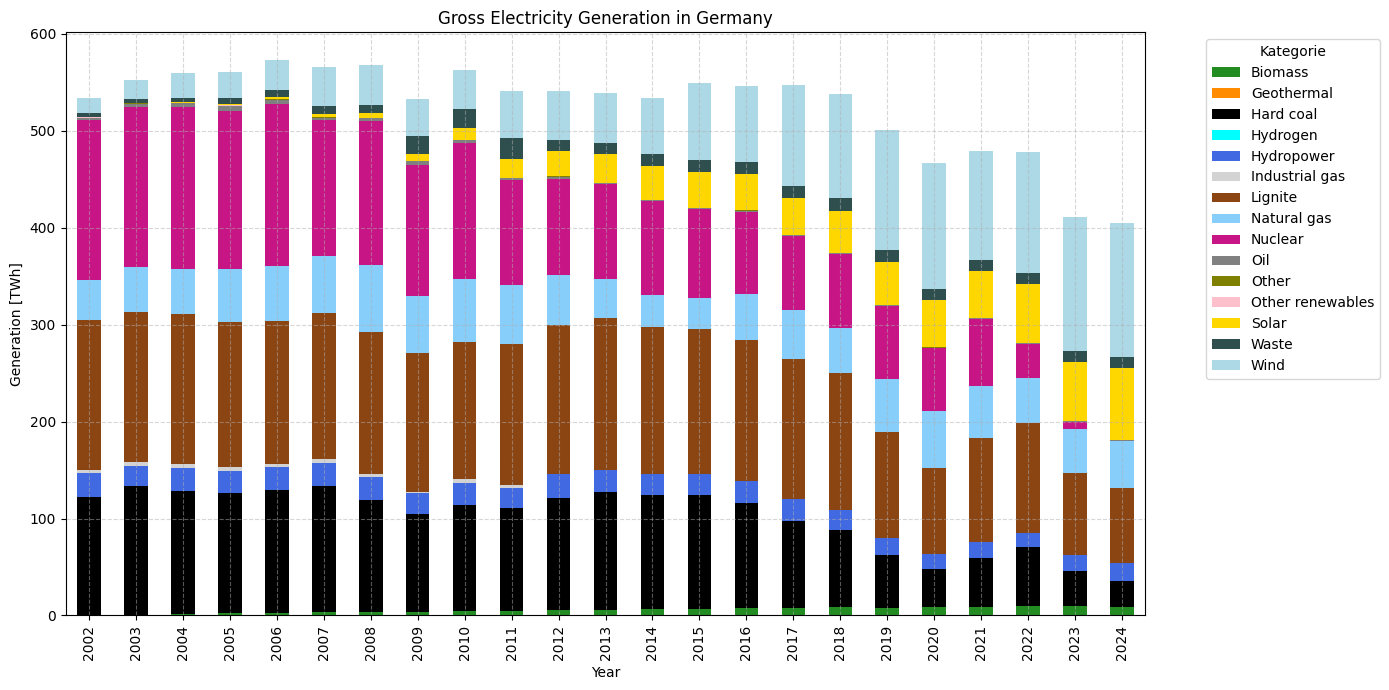

In [ ]:
# Pivot Plot
pivot_plot = DF_STROMMIX.pivot_table(index="year", columns="Category", values="value", aggfunc="sum").fillna(0)

# MWh -> TWh Conversion for better readability
pivot_plot= pivot_plot / 1_000_000

# Plot
categories = list(pivot_plot.columns)
colors = [COLOR_MAP.get(cat, "gray") for cat in categories]

pivot_plot.plot(kind="bar", stacked=True, figsize=(14, 7), color=colors)

plt.title("Gross Electricity Generation in Germany")
plt.xlabel("Year")
plt.ylabel("Generation [TWh]")
plt.legend(title="Kategorie", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "DF_STROMMIX.png"), dpi=300, bbox_inches="tight")
plt.show()


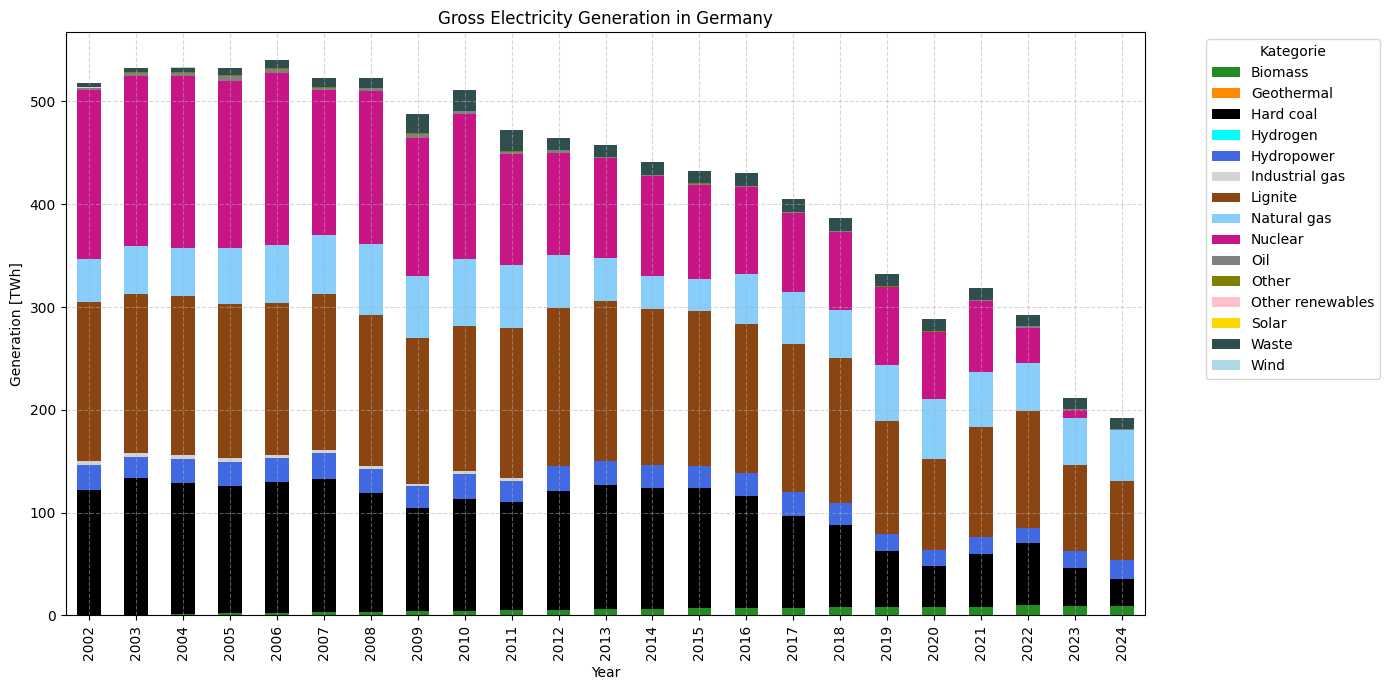

<Figure size 640x480 with 0 Axes>

In [15]:
# Pivot Plot für DF_3_CATEGORIZED
pivot_plot_1 = DF_1_CATEGORIZED.pivot_table(index="year", columns="Category", values="value", aggfunc="sum").fillna(0)

# MWh -> TWh Conversion for better readability
pivot_plot_1 = pivot_plot_1 / 1_000_000

# Farben in Spaltenreihenfolge bringen
categories_1 = list(pivot_plot_1.columns)
colors_1 = [COLOR_MAP.get(cat, "gray") for cat in categories_1]

# Plot
pivot_plot_1.plot(kind="bar", stacked=True, figsize=(14, 7), color=colors_1)

plt.title("Gross Electricity Generation in Germany")
plt.xlabel("Year")
plt.ylabel("Generation [TWh]")
plt.legend(title="Kategorie", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.savefig(os.path.join(PLOT_DIR, "DF_1.png"), dpi=300, bbox_inches="tight")


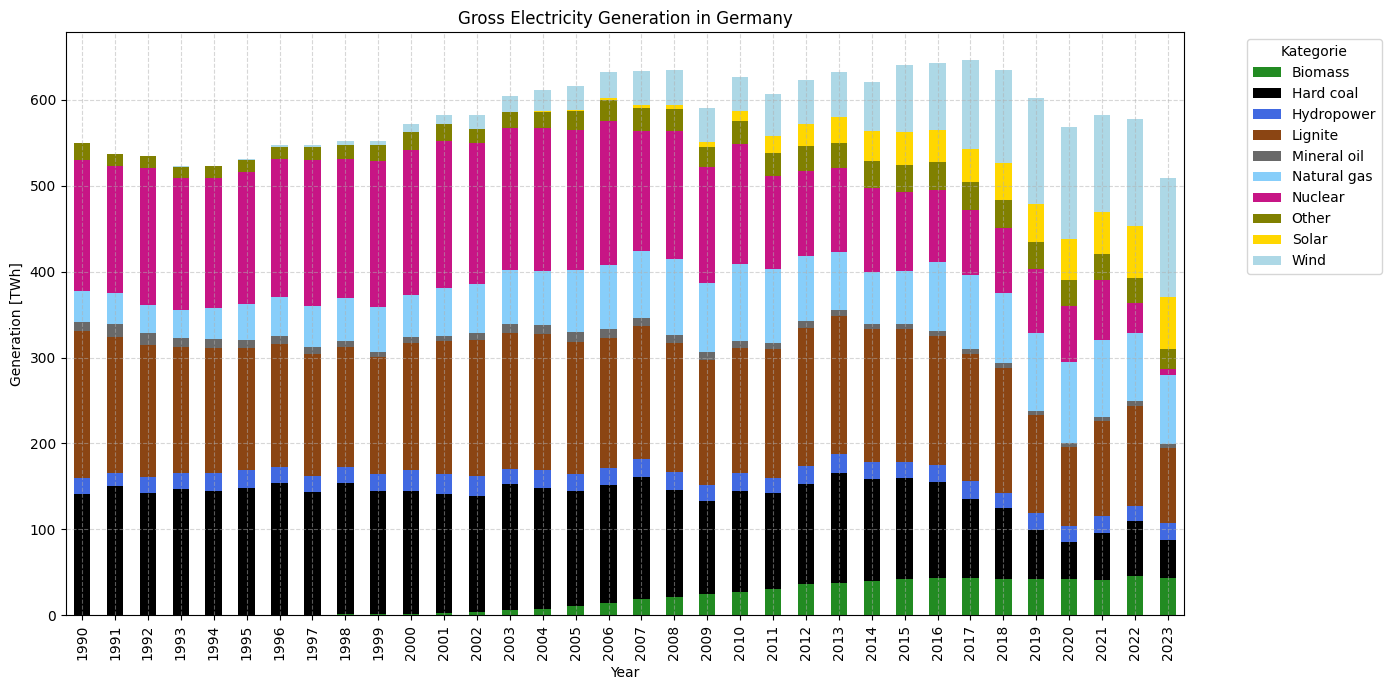

<Figure size 640x480 with 0 Axes>

In [17]:
# Pivot Plot für DF_3_CATEGORIZED
pivot_plot_3 = DF_3_CATEGORIZED.pivot_table(index="year", columns="Category", values="value", aggfunc="sum").fillna(0)

# MWh -> TWh Conversion for better readability
pivot_plot_3 = pivot_plot_3 / 1_000_000

# Farben in Spaltenreihenfolge bringen
categories_3 = list(pivot_plot_3.columns)
colors_3 = [COLOR_MAP.get(cat, "gray") for cat in categories_3]

# Plot
pivot_plot_3.plot(kind="bar", stacked=True, figsize=(14, 7), color=colors_3)

plt.title("Gross Electricity Generation in Germany")
plt.xlabel("Year")
plt.ylabel("Generation [TWh]")
plt.legend(title="Kategorie", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

plt.savefig(os.path.join(PLOT_DIR, "DF_3.png"), dpi=300, bbox_inches="tight")
